# 시각화: 양자 오토인코더 회로 아키텍처

이 노트북은 '양자 오토인코더를 위한 고급 회로 아키텍처' 문서에 설명된 다양한 회로 구조를 시각화합니다.

각 코드 셀을 실행하여 해당 아키텍처의 회로도를 생성하고 확인할 수 있습니다.

## 구현된 아키텍처 개요

### 기본 아키텍처
1. **QAE_Angle**: 기준선 양자 오토인코더 (각도 임베딩 + 변분 안사츠)

### 고급 아키텍처
2. **Enhanced qVAE**: 전체 큐비트 구조 (데이터 + 보조 큐비트) + 데이터 재업로딩
3. **HEA**: 계층적 얽힘 안사츠 (지역적 → 권역적 → 전역적 얽힘)
4. **CIE**: 공분산 정보 기반 얽힘 (데이터 상관관계 활용)

### 임베딩 혁신
5. **CTE**: 체비쇼프 타워 임베딩 (고차 다항식 특징 추출)
6. **IQP**: 학습 가능한 순간 양자 다항식 임베딩

### 특수 기법
7. **DIFE**: 상쇄 간섭 충실도 추정 (양자 상태 품질 평가)
8. **LS-SWAP**: 잠재 공간 SWAP 테스트 (큐비트 효율적 유사도 측정)

각 회로는 문서의 이론적 기반을 바탕으로 구현되었으며, 실제 양자 머신러닝 응용에 활용할 수 있습니다.

## 1. QAE_Angle (기준선)

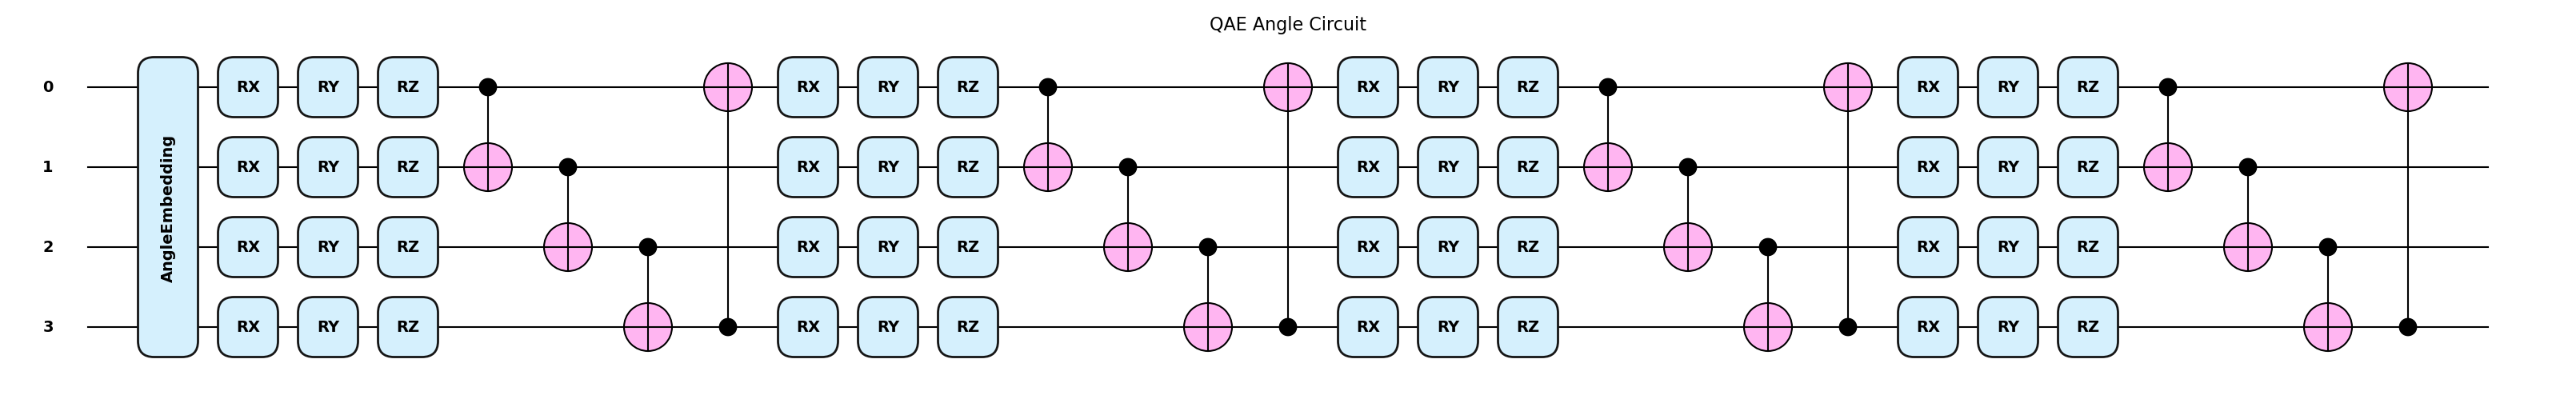

In [18]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# 1. QAE_Angle (기준선)
num_qubits_angle = 4
dev_angle = qml.device("default.qubit", wires=num_qubits_angle)

@qml.qnode(dev_angle)
def qae_angle_circuit(inputs, weights):
    # 데이터 임베딩
    qml.AngleEmbedding(inputs, wires=range(num_qubits_angle))
    # 4개의 변형 레이어
    for i in range(4):
        for j in range(num_qubits_angle):
            qml.RX(weights[i, j, 0], wires=j)
            qml.RY(weights[i, j, 1], wires=j)
            qml.RZ(weights[i, j, 2], wires=j)
        # 순환 CNOT 얽힘 (ring pattern을 직접 구현)
        for j in range(num_qubits_angle):
            qml.CNOT(wires=[j, (j + 1) % num_qubits_angle])

# 그리기 위한 더미 입력값
dummy_inputs_angle = np.zeros(num_qubits_angle)
dummy_weights_angle = np.zeros((4, num_qubits_angle, 3))

# 회로 시각화 (matplotlib 백엔드 사용)
fig, ax = qml.draw_mpl(qae_angle_circuit, style="pennylane", expansion_strategy="device")(dummy_inputs_angle, dummy_weights_angle)
fig.suptitle("QAE Angle Circuit", fontsize=16)
plt.show()

## 2. Enhanced qVAE (인코더 부분)

Enhanced qVAE 아키텍처 (총 13개 큐비트):
- 데이터 큐비트: 8개 (큐비트 0-7) - 4개 특징 × 2개 복사본
- 참조 큐비트: 2개 (큐비트 8-9) - SWAP 테스트용
- 트래시 큐비트: 2개 (큐비트 10-11) - 측정용 보조
- 제어 큐비트: 1개 (큐비트 12) - SWAP 테스트 제어



C:\Users\김성수\AppData\Local\Temp\ipykernel_11132\2163750543.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\ProgramData\anaconda3\envs\my312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\envs\my312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\envs\my312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45908 (\N{HANGUL SYLLABLE DEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\envs\my312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaV

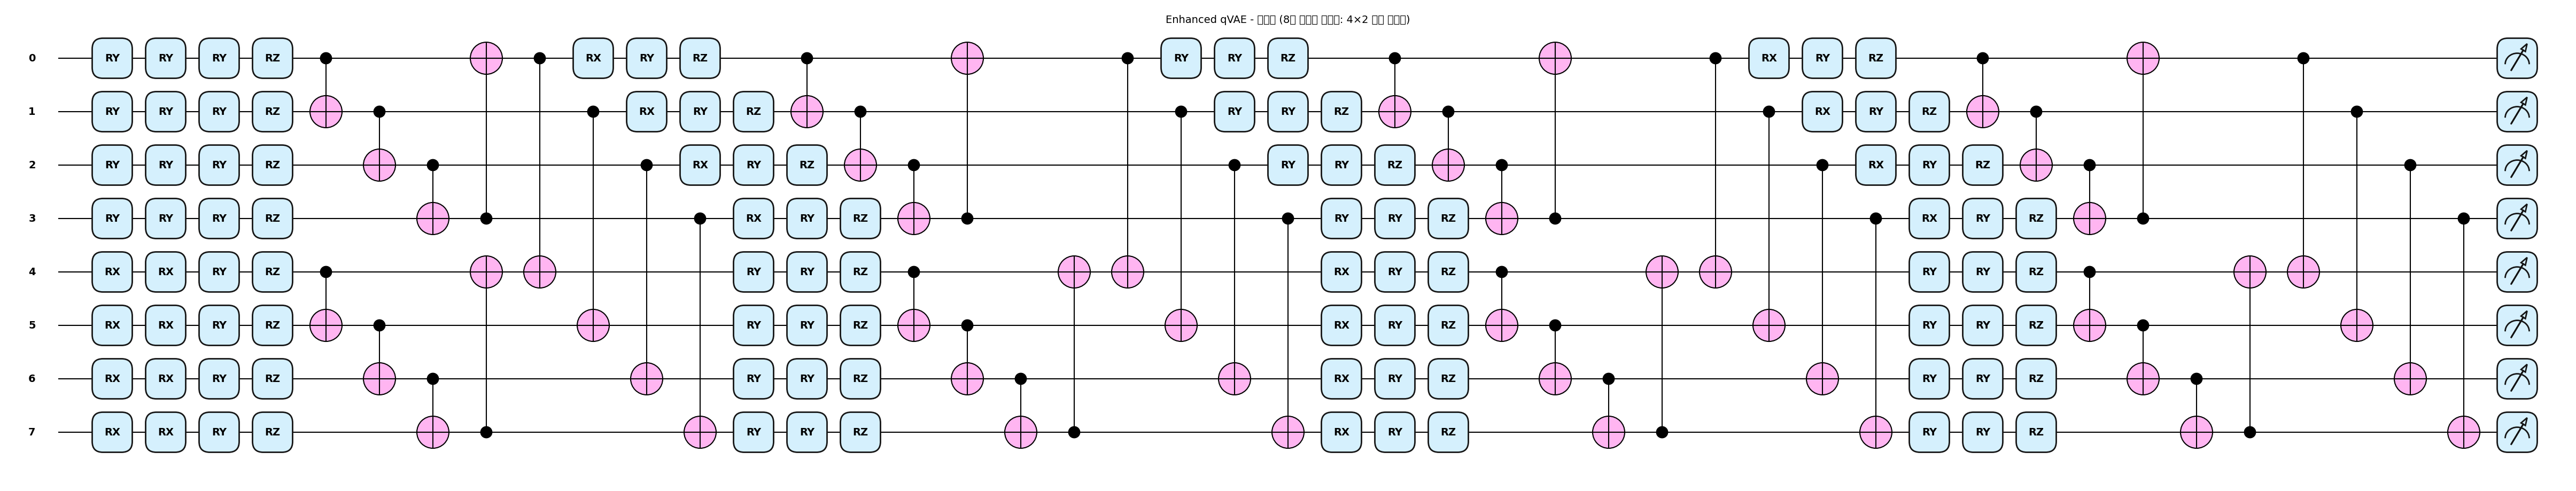

C:\Users\김성수\AppData\Local\Temp\ipykernel_11132\2163750543.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\ProgramData\anaconda3\envs\my312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\envs\my312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\envs\my312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\envs\my312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52280 (\N{HANGUL SYLLABLE CAM}) missing from font(s) Dej

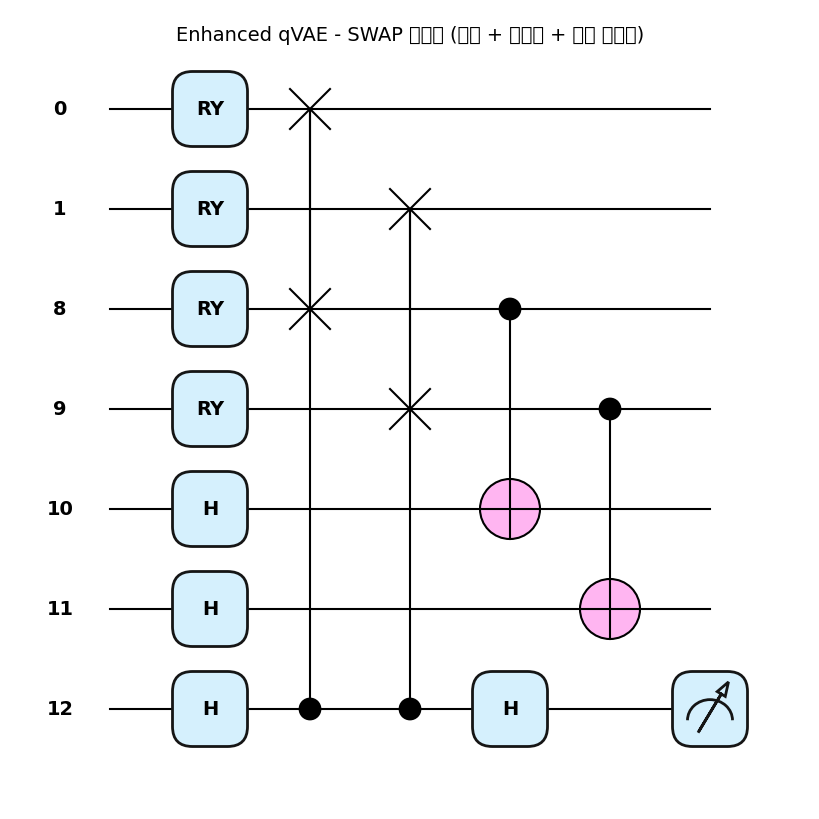

C:\Users\김성수\AppData\Local\Temp\ipykernel_11132\2163750543.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\ProgramData\anaconda3\envs\my312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\envs\my312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\envs\my312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\envs\my312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) Dej

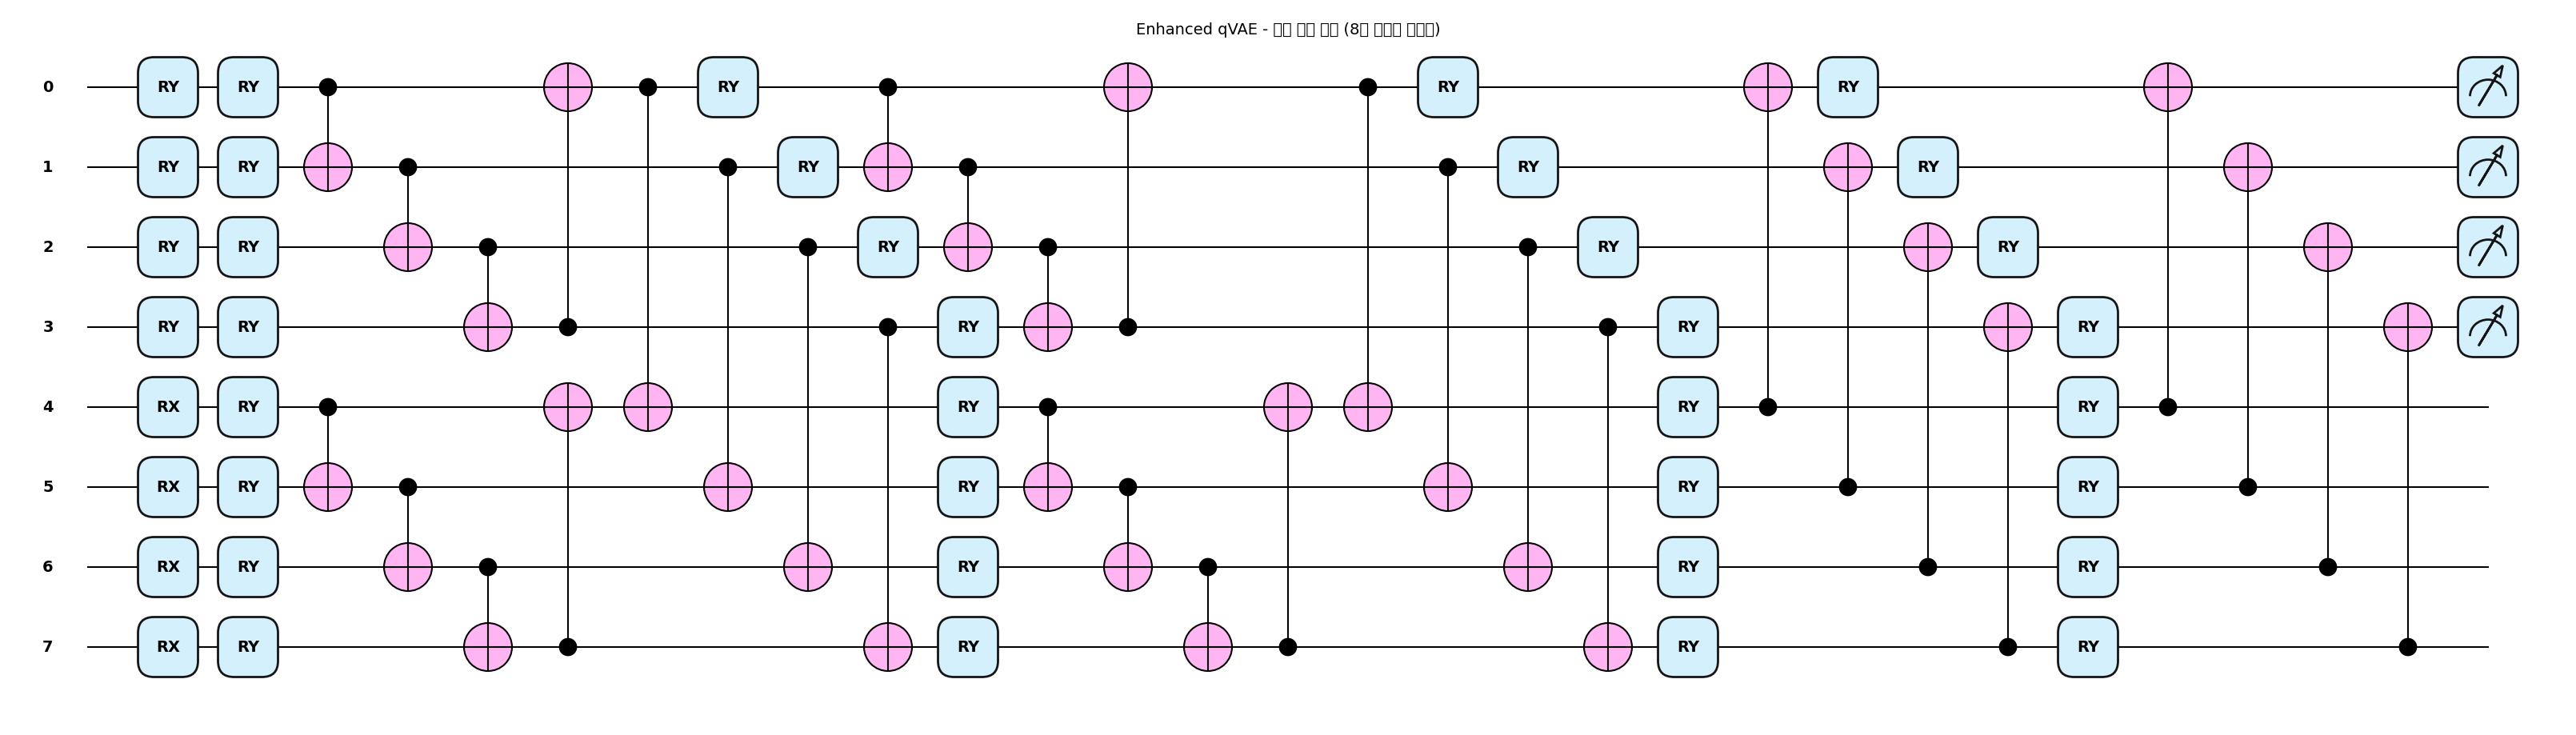

C:\Users\김성수\AppData\Local\Temp\ipykernel_11132\2163750543.py:216: UserWarning: Glyph 53328 (\N{HANGUL SYLLABLE KYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\김성수\AppData\Local\Temp\ipykernel_11132\2163750543.py:216: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\김성수\AppData\Local\Temp\ipykernel_11132\2163750543.py:216: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\김성수\AppData\Local\Temp\ipykernel_11132\2163750543.py:216: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\김성수\AppData\Local\Temp\ipykernel_11132\2163750543.py:216: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\김성수\AppData\Local\Temp\ipykernel_11132\2163750543.py:216: UserWarning: Glyph 54624 (\N{HANGUL SYLLABLE HAL}) missing from font(

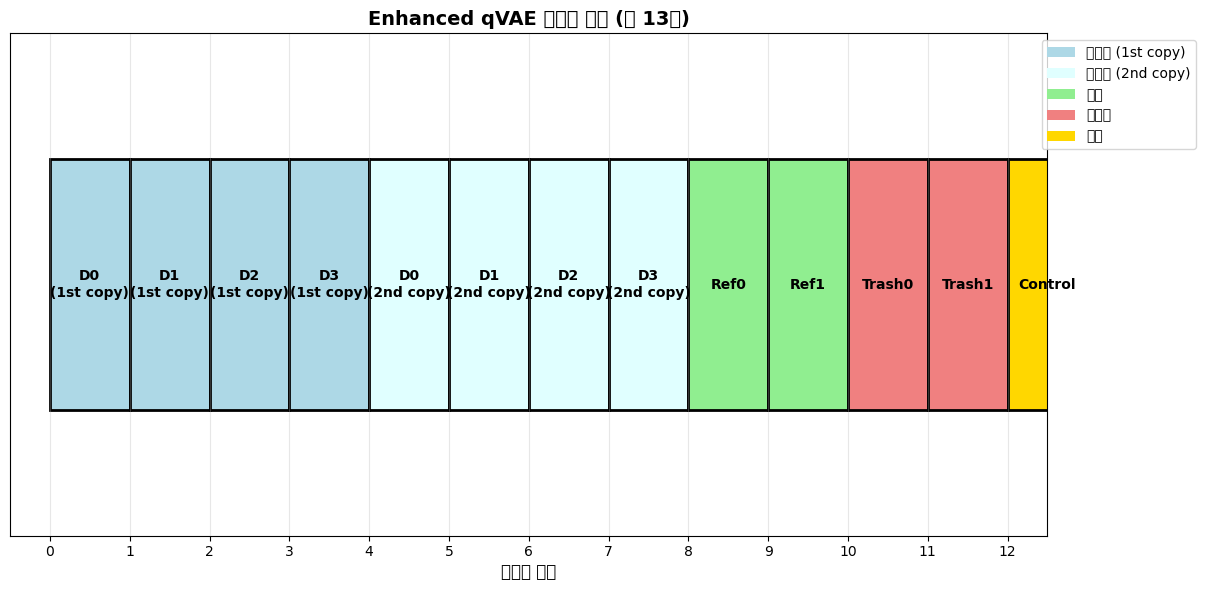


=== Enhanced qVAE 아키텍처 상세 ===
총 큐비트 수: 13개
1. 데이터 큐비트: 8개
   - 1st copy: 큐비트 0-3 (4개 특징)
   - 2nd copy: 큐비트 4-7 (4개 특징 복사)
2. 참조 큐비트: 2개 (큐비트 8-9)
3. 트래시 큐비트: 2개 (큐비트 10-11)
4. 제어 큐비트: 1개 (큐비트 12)

특징:
- 병렬 데이터 임베딩: 각 특징을 2개 큐비트에 인코딩
- 데이터 재업로딩: 각 레이어에서 데이터 재입력
- SWAP 테스트: 잠재 공간과 참조 상태 간 유사도 측정
- 트래시 큐비트: 측정 보조 및 노이즈 처리


In [19]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# 2. Enhanced qVAE (전체 13큐비트 구조)
# 아키텍처: 8 data + 2 ref + 2 trash + 1 control = 13 qubits total
num_data_qubits = 8      # 4*2 parallel data encoding (4 features × 2 copies)
num_ref_qubits = 2       # Reference qubits for SWAP test
num_trash_qubits = 2     # Trash qubits for measurements
num_control_qubits = 1   # Control qubit for SWAP test
num_total_qubits = num_data_qubits + num_ref_qubits + num_trash_qubits + num_control_qubits

# 큐비트 할당
data_wires = list(range(num_data_qubits))                    # 0-7: Data qubits
ref_wires = list(range(num_data_qubits, num_data_qubits + num_ref_qubits))  # 8-9: Reference
trash_wires = list(range(num_data_qubits + num_ref_qubits, 
                        num_data_qubits + num_ref_qubits + num_trash_qubits))  # 10-11: Trash
control_wire = num_total_qubits - 1                          # 12: Control

dev_enhanced = qml.device("default.qubit", wires=num_total_qubits)

print(f"Enhanced qVAE 아키텍처 (총 {num_total_qubits}개 큐비트):")
print(f"- 데이터 큐비트: {num_data_qubits}개 (큐비트 {data_wires[0]}-{data_wires[-1]}) - 4개 특징 × 2개 복사본")
print(f"- 참조 큐비트: {num_ref_qubits}개 (큐비트 {ref_wires[0]}-{ref_wires[-1]}) - SWAP 테스트용")
print(f"- 트래시 큐비트: {num_trash_qubits}개 (큐비트 {trash_wires[0]}-{trash_wires[-1]}) - 측정용 보조")
print(f"- 제어 큐비트: {num_control_qubits}개 (큐비트 {control_wire}) - SWAP 테스트 제어")
print()

# === 1. 인코더 회로 시각화 ===
@qml.qnode(dev_enhanced)
def enhanced_qvae_encoder(inputs, encoder_weights):
    """Enhanced qVAE 인코더 부분 (데이터 임베딩 + 변분 레이어)"""
    
    # 병렬 데이터 임베딩 (4개 특징을 8개 큐비트에 2번씩)
    for i in range(4):
        # 첫 번째 복사본 (큐비트 0-3)
        qml.RY(inputs[i], wires=i)
        # 두 번째 복사본 (큐비트 4-7)
        qml.RX(inputs[i], wires=i + 4)
    
    # 4개의 변형 레이어 (데이터 재업로딩 포함)
    for layer in range(4):
        # 데이터 재업로딩 (병렬 임베딩)
        for i in range(4):
            if layer % 2 == 0:
                qml.RY(inputs[i] * 0.5, wires=i)      # 첫 번째 복사본
                qml.RX(inputs[i] * 0.5, wires=i + 4)  # 두 번째 복사본
            else:
                qml.RX(inputs[i] * 0.5, wires=i)      # 교대로 다른 회전
                qml.RY(inputs[i] * 0.5, wires=i + 4)
        
        # 변형 안사츠 레이어 (데이터 큐비트에만)
        for j in range(num_data_qubits):
            qml.RY(encoder_weights[layer, j, 0], wires=j)
            qml.RZ(encoder_weights[layer, j, 1], wires=j)
        
        # 얽힘 레이어
        # 각 복사본 내 순환 얽힘
        for j in range(4):
            qml.CNOT(wires=[j, (j + 1) % 4])          # 첫 번째 복사본 (0-3)
            qml.CNOT(wires=[j + 4, (j + 1) % 4 + 4])  # 두 번째 복사본 (4-7)
        
        # 복사본 간 교차 얽힘
        for j in range(4):
            qml.CNOT(wires=[j, j + 4])  # 첫 번째 → 두 번째 복사본
    
    return [qml.expval(qml.PauliZ(i)) for i in range(num_data_qubits)]

# 인코더 시각화
dummy_inputs = np.array([0.1, 0.2, 0.3, 0.4])  # 4개 특징
dummy_encoder_weights = np.random.normal(0, 0.1, (4, num_data_qubits, 2))

fig1, ax1 = qml.draw_mpl(enhanced_qvae_encoder, style="pennylane", expansion_strategy="device")(
    dummy_inputs, dummy_encoder_weights
)
fig1.suptitle("Enhanced qVAE - 인코더 (8개 데이터 큐비트: 4×2 병렬 임베딩)", fontsize=14)
plt.tight_layout()
plt.show()

# === 2. SWAP 테스트 회로 시각화 ===
@qml.qnode(dev_enhanced)
def enhanced_qvae_swap_test(latent_params, ref_params):
    """Enhanced qVAE SWAP 테스트 부분 (잠재 공간 + 참조 + 제어)"""
    
    # 잠재 공간 상태 준비 (데이터 큐비트의 일부를 잠재 공간으로 사용)
    latent_qubits = [0, 1]  # 첫 번째 복사본의 처음 2개 큐비트를 잠재 공간으로
    for i, qubit in enumerate(latent_qubits):
        qml.RY(latent_params[i], wires=qubit)
    
    # 참조 상태 준비
    for i, wire in enumerate(ref_wires):
        qml.RY(ref_params[i], wires=wire)
    
    # 트래시 큐비트 초기화 (측정 보조용)
    for wire in trash_wires:
        qml.Hadamard(wires=wire)
    
    # SWAP 테스트 프로토콜
    qml.Hadamard(wires=control_wire)
    
    # 조건부 SWAP 연산들
    for i in range(len(latent_qubits)):
        qml.CSWAP(wires=[control_wire, latent_qubits[i], ref_wires[i]])
    
    # 트래시 큐비트와의 추가 얽힘 (측정 보조)
    for i, trash_wire in enumerate(trash_wires):
        if i < len(ref_wires):
            qml.CNOT(wires=[ref_wires[i], trash_wire])
    
    qml.Hadamard(wires=control_wire)
    
    return qml.expval(qml.PauliZ(control_wire))

# SWAP 테스트 시각화
dummy_latent_params = np.array([0.5, 0.6])
dummy_ref_params = np.array([0.3, 0.4])

fig2, ax2 = qml.draw_mpl(enhanced_qvae_swap_test, style="pennylane", expansion_strategy="device")(
    dummy_latent_params, dummy_ref_params
)
fig2.suptitle("Enhanced qVAE - SWAP 테스트 (참조 + 트래시 + 제어 큐비트)", fontsize=14)
plt.tight_layout()
plt.show()

# === 3. 전체 회로 시각화 (간소화 버전) ===
@qml.qnode(qml.device("default.qubit", wires=8))  # 시각화를 위해 8큐비트로 제한
def enhanced_qvae_simplified_full(inputs, encoder_weights, decoder_weights):
    """Enhanced qVAE 전체 회로 (간소화 - 8큐비트만)"""
    
    # 인코더 (간소화)
    for i in range(4):
        qml.RY(inputs[i], wires=i)      # 첫 번째 복사본
        qml.RX(inputs[i], wires=i + 4)  # 두 번째 복사본
    
    # 변형 레이어 (2개만)
    for layer in range(2):
        for j in range(8):
            qml.RY(encoder_weights[layer, j], wires=j)
        
        # 얽힘
        for j in range(4):
            qml.CNOT(wires=[j, (j + 1) % 4])
            qml.CNOT(wires=[j + 4, (j + 1) % 4 + 4])
        for j in range(4):
            qml.CNOT(wires=[j, j + 4])
    
    # 디코더 (간소화)
    for layer in range(2):
        for j in range(8):
            qml.RY(decoder_weights[layer, j], wires=j)
        
        for j in range(4):
            qml.CNOT(wires=[j + 4, j])  # 역방향 정보 전파
    
    return [qml.expval(qml.PauliZ(i)) for i in range(4)]

# 전체 회로 시각화 (간소화)
dummy_encoder_weights_simple = np.random.normal(0, 0.1, (2, 8))
dummy_decoder_weights_simple = np.random.normal(0, 0.1, (2, 8))

fig3, ax3 = qml.draw_mpl(enhanced_qvae_simplified_full, style="pennylane", expansion_strategy="device")(
    dummy_inputs, dummy_encoder_weights_simple, dummy_decoder_weights_simple
)
fig3.suptitle("Enhanced qVAE - 전체 회로 개요 (8개 데이터 큐비트)", fontsize=14)
plt.tight_layout()
plt.show()

# === 4. 큐비트 할당 시각화 ===
fig4, ax4 = plt.subplots(1, 1, figsize=(12, 6))

# 큐비트 레이블과 색상
qubit_labels = []
colors = []
for i in range(num_total_qubits):
    if i in data_wires:
        if i < 4:
            qubit_labels.append(f"D{i}\n(1st copy)")
            colors.append('lightblue')
        else:
            qubit_labels.append(f"D{i-4}\n(2nd copy)")
            colors.append('lightcyan')
    elif i in ref_wires:
        qubit_labels.append(f"Ref{i-8}")
        colors.append('lightgreen')
    elif i in trash_wires:
        qubit_labels.append(f"Trash{i-10}")
        colors.append('lightcoral')
    else:  # control
        qubit_labels.append("Control")
        colors.append('gold')

# 큐비트 그리기
y_pos = 0
for i, (label, color) in enumerate(zip(qubit_labels, colors)):
    rect = plt.Rectangle((i, y_pos), 1, 1, facecolor=color, edgecolor='black', linewidth=2)
    ax4.add_patch(rect)
    ax4.text(i + 0.5, y_pos + 0.5, label, ha='center', va='center', fontsize=10, fontweight='bold')

ax4.set_xlim(-0.5, num_total_qubits - 0.5)
ax4.set_ylim(-0.5, 1.5)
ax4.set_xlabel('큐비트 번호', fontsize=12)
ax4.set_title('Enhanced qVAE 큐비트 할당 (총 13개)', fontsize=14, fontweight='bold')
ax4.set_xticks(range(num_total_qubits))
ax4.set_yticks([])
ax4.grid(True, alpha=0.3)

# 범례
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor='lightblue', label='데이터 (1st copy)'),
    plt.Rectangle((0, 0), 1, 1, facecolor='lightcyan', label='데이터 (2nd copy)'),
    plt.Rectangle((0, 0), 1, 1, facecolor='lightgreen', label='참조'),
    plt.Rectangle((0, 0), 1, 1, facecolor='lightcoral', label='트래시'),
    plt.Rectangle((0, 0), 1, 1, facecolor='gold', label='제어')
]
ax4.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

print("\n=== Enhanced qVAE 아키텍처 상세 ===")
print(f"총 큐비트 수: {num_total_qubits}개")
print(f"1. 데이터 큐비트: {num_data_qubits}개")
print(f"   - 1st copy: 큐비트 0-3 (4개 특징)")
print(f"   - 2nd copy: 큐비트 4-7 (4개 특징 복사)")
print(f"2. 참조 큐비트: {num_ref_qubits}개 (큐비트 8-9)")
print(f"3. 트래시 큐비트: {num_trash_qubits}개 (큐비트 10-11)")
print(f"4. 제어 큐비트: {num_control_qubits}개 (큐비트 12)")
print(f"\n특징:")
print("- 병렬 데이터 임베딩: 각 특징을 2개 큐비트에 인코딩")
print("- 데이터 재업로딩: 각 레이어에서 데이터 재입력")
print("- SWAP 테스트: 잠재 공간과 참조 상태 간 유사도 측정")
print("- 트래시 큐비트: 측정 보조 및 노이즈 처리")

## 3. HEA (계층적 얽힘 안사츠)

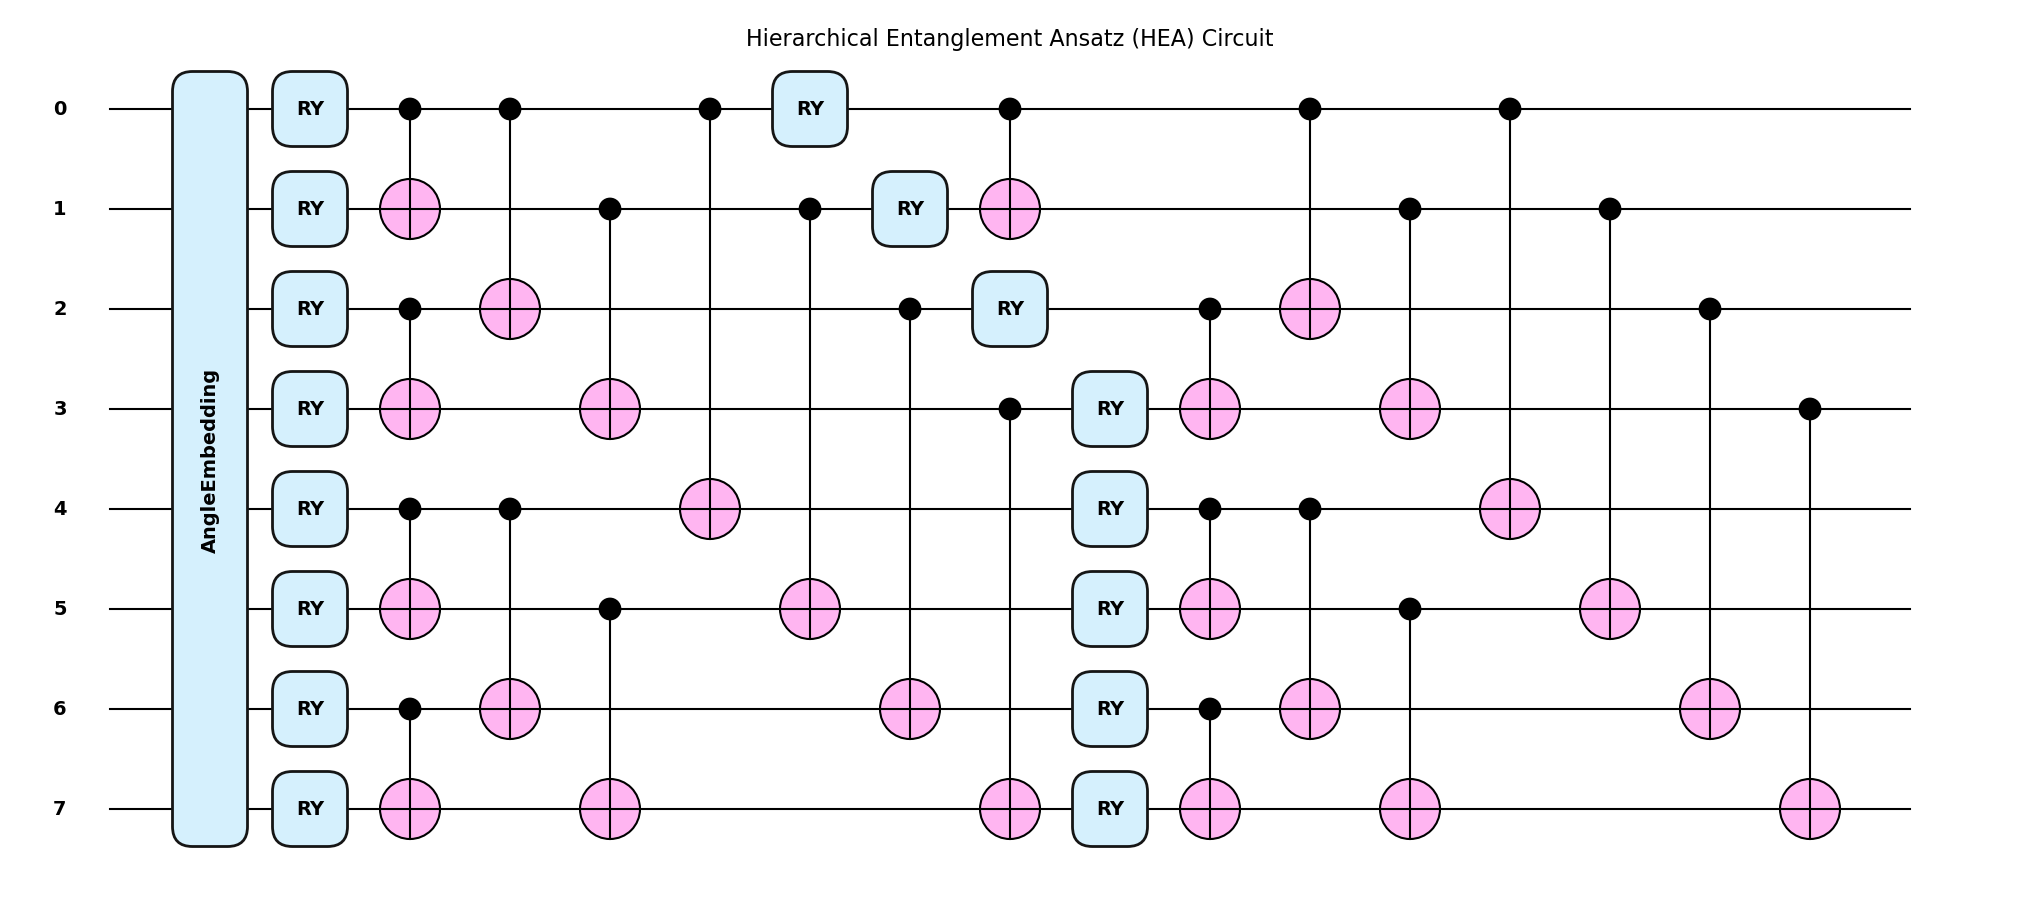

In [20]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# 3. HEA (계층적 얽힘 안사츠)
num_qubits_hea = 8
dev_hea = qml.device("default.qubit", wires=num_qubits_hea)

@qml.qnode(dev_hea)
def hea_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(num_qubits_hea))
    # 2개 레이어만 시각화를 위해 표시
    for i in range(2):
        # RY 회전 게이트들을 각 큐비트에 적용
        for j in range(num_qubits_hea):
            qml.RY(weights[i, j], wires=j)
        
        # 계층적 CNOTs
        # 1단계 (지역적): (0,1), (2,3), ...
        for j in range(0, num_qubits_hea, 2): 
            if j + 1 < num_qubits_hea:
                qml.CNOT(wires=[j, j+1])
        
        # 2단계 (권역적): (0,2), (1,3), ...
        for j in range(0, num_qubits_hea, 4):
            if j + 2 < num_qubits_hea:
                qml.CNOT(wires=[j, j+2])
            if j + 3 < num_qubits_hea:
                qml.CNOT(wires=[j+1, j+3])
        
        # 3단계 (전역적): (0,4), (1,5), ...
        for j in range(0, num_qubits_hea // 2): 
            if j + num_qubits_hea // 2 < num_qubits_hea:
                qml.CNOT(wires=[j, j + num_qubits_hea // 2])

# 그리기 위한 더미 입력값
dummy_inputs_hea = np.zeros(num_qubits_hea)
dummy_weights_hea = np.zeros((2, num_qubits_hea))

# 회로 시각화 (matplotlib 백엔드 사용)
fig, ax = qml.draw_mpl(hea_circuit, style="pennylane", expansion_strategy="device")(dummy_inputs_hea, dummy_weights_hea)
fig.suptitle("Hierarchical Entanglement Ansatz (HEA) Circuit", fontsize=16)
plt.show()

## 4. CIE (공분산 정보 기반 얽힘) - 예시

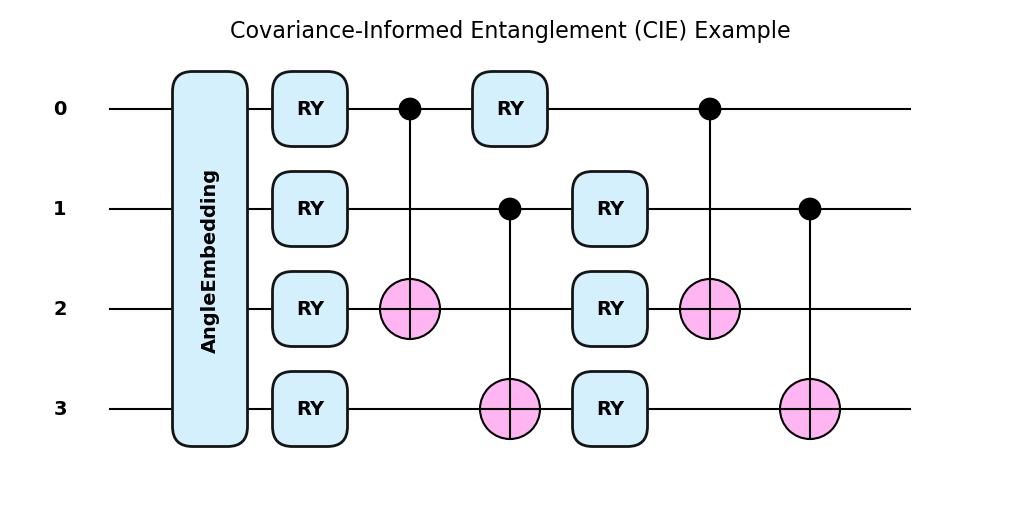

In [21]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# 4. CIE (공분산 정보 기반 얽힘) - 예시
num_qubits_cie = 4
dev_cie = qml.device("default.qubit", wires=num_qubits_cie)

@qml.qnode(dev_cie)
def cie_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(num_qubits_cie))
    # 2개 레이어
    for i in range(2):
        # RY 회전 게이트들을 각 큐비트에 적용
        for j in range(num_qubits_cie):
            qml.RY(weights[i, j], wires=j)
        
        # 사전 계산된 공분산에 따라 (0, 2)와 (1, 3)이 강하게 상관되어 있다고 가정
        qml.CNOT(wires=[0, 2])
        qml.CNOT(wires=[1, 3])

# 그리기 위한 더미 입력값
dummy_inputs_cie = np.zeros(num_qubits_cie)
dummy_weights_cie = np.zeros((2, num_qubits_cie))

# 회로 시각화 (matplotlib 백엔드 사용)
fig, ax = qml.draw_mpl(cie_circuit, style="pennylane", expansion_strategy="device")(dummy_inputs_cie, dummy_weights_cie)
fig.suptitle("Covariance-Informed Entanglement (CIE) Example", fontsize=16)
plt.show()

## 5. CTE (체비쇼프 타워 임베딩)

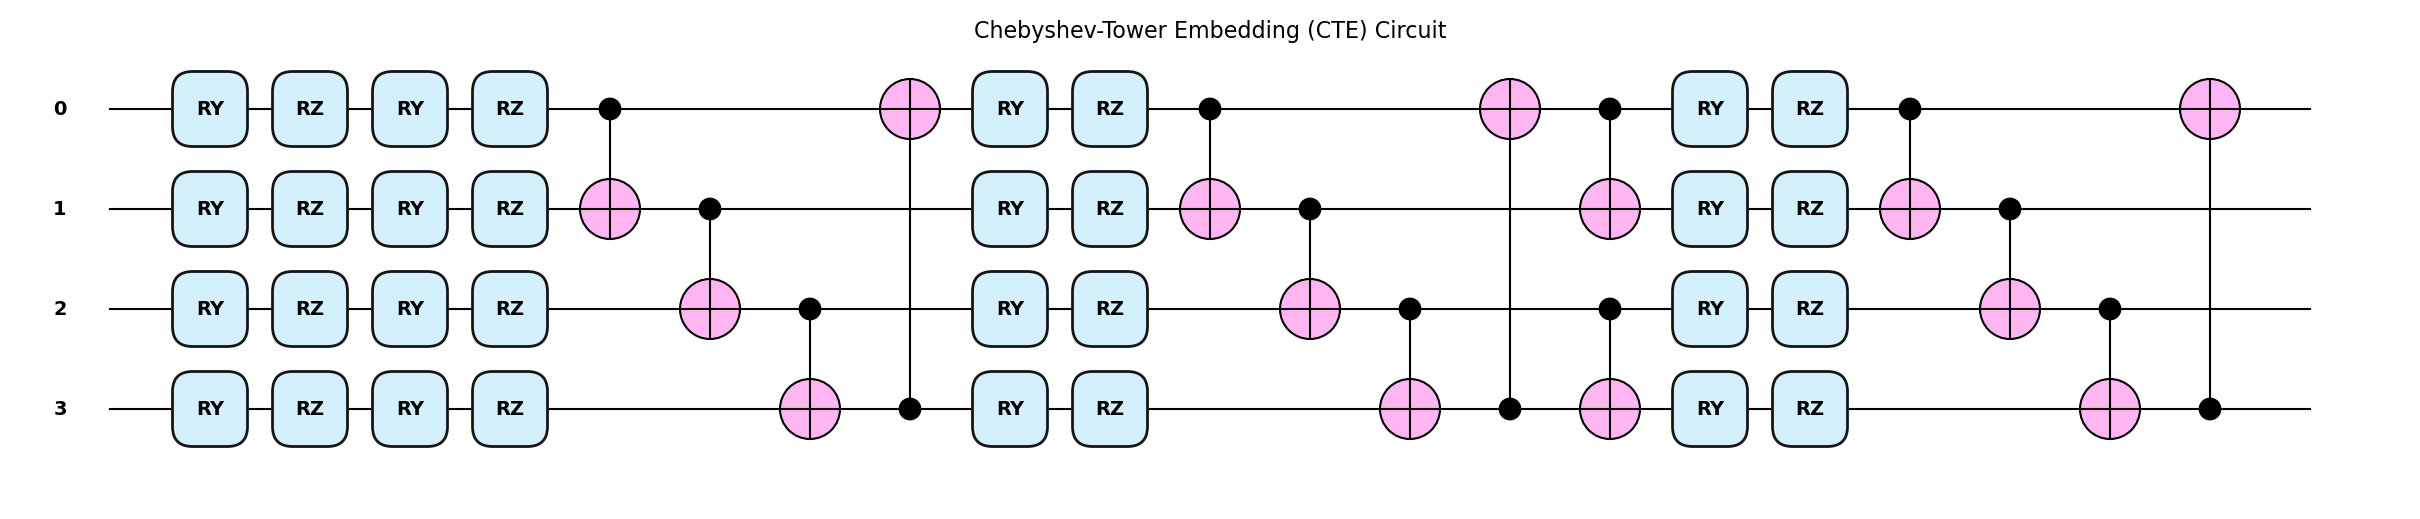

체비쇼프 다항식 최대 차수: 2
임베딩 매개변수 수: 16개
안사츠 매개변수 수: 24개


In [22]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# 5. CTE (체비쇼프 타워 임베딩)
num_qubits_cte = 4
max_degree = 2  # M=2 (최대 2차 다항식)
dev_cte = qml.device("default.qubit", wires=num_qubits_cte)

def chebyshev_polynomials(x, max_degree):
    """체비쇼프 다항식 T_n(x) 계산 (n=0 to max_degree)"""
    polys = [1.0]  # T_0(x) = 1
    if max_degree >= 1:
        polys.append(x)  # T_1(x) = x
    
    # 재귀 관계: T_{n+1}(x) = 2x*T_n(x) - T_{n-1}(x)
    for n in range(2, max_degree + 1):
        next_poly = 2 * x * polys[n-1] - polys[n-2]
        polys.append(next_poly)
    
    return polys

def chebyshev_tower_embedding(inputs, alpha_params):
    """체비쇼프 타워 임베딩: φ(x) = Σ α_n * T_n(x)"""
    for i, x in enumerate(inputs):
        # 정규화된 입력 ([-1, 1] 범위로)
        x_normalized = np.tanh(x)  # 또는 다른 정규화 함수
        
        # 체비쇼프 다항식 계산
        chebyshev_values = chebyshev_polynomials(x_normalized, max_degree)
        
        # 타워 임베딩: φ(x) = Σ α_n * T_n(x)
        embedding_angle = 0.0
        for n in range(max_degree + 1):
            embedding_angle += alpha_params[i, n] * chebyshev_values[n]
        
        # 임베딩 각도를 회전 게이트에 적용
        qml.RY(embedding_angle, wires=i)
        
        # 추가적인 표현력을 위한 보조 회전
        qml.RZ(alpha_params[i, max_degree + 1], wires=i)

@qml.qnode(dev_cte)
def cte_circuit(inputs, alpha_params, weights):
    # 체비쇼프 타워 임베딩
    chebyshev_tower_embedding(inputs, alpha_params)
    
    # 변형 안사츠 적용
    for i in range(3):  # 레이어 수 증가
        # 매개변수화된 회전 게이트
        for j in range(num_qubits_cte):
            qml.RY(weights[i, j, 0], wires=j)
            qml.RZ(weights[i, j, 1], wires=j)
        
        # 얽힘 패턴: 순환 + 선형
        for j in range(num_qubits_cte):
            qml.CNOT(wires=[j, (j + 1) % num_qubits_cte])
        
        # 추가 얽힘 (홀수 레이어에서)
        if i % 2 == 1:
            for j in range(0, num_qubits_cte - 1, 2):
                qml.CNOT(wires=[j, j + 1])

# 그리기 위한 더미 입력값
dummy_inputs_cte = np.array([0.1, 0.2, 0.3, 0.4])  # 비영 입력값으로 변경
dummy_weights_cte = np.zeros((3, num_qubits_cte, 2))
dummy_alphas_cte = np.random.normal(0, 0.1, (num_qubits_cte, max_degree + 2))  # α 매개변수

# 회로 시각화 (matplotlib 백엔드 사용)
fig, ax = qml.draw_mpl(cte_circuit, style="pennylane", expansion_strategy="device")(
    dummy_inputs_cte, dummy_alphas_cte, dummy_weights_cte
)
fig.suptitle("Chebyshev-Tower Embedding (CTE) Circuit", fontsize=16)
plt.show()

print(f"체비쇼프 다항식 최대 차수: {max_degree}")
print(f"임베딩 매개변수 수: {(max_degree + 2) * num_qubits_cte}개")
print(f"안사츠 매개변수 수: {3 * num_qubits_cte * 2}개")

## 6. IQP (학습 가능한) 임베딩

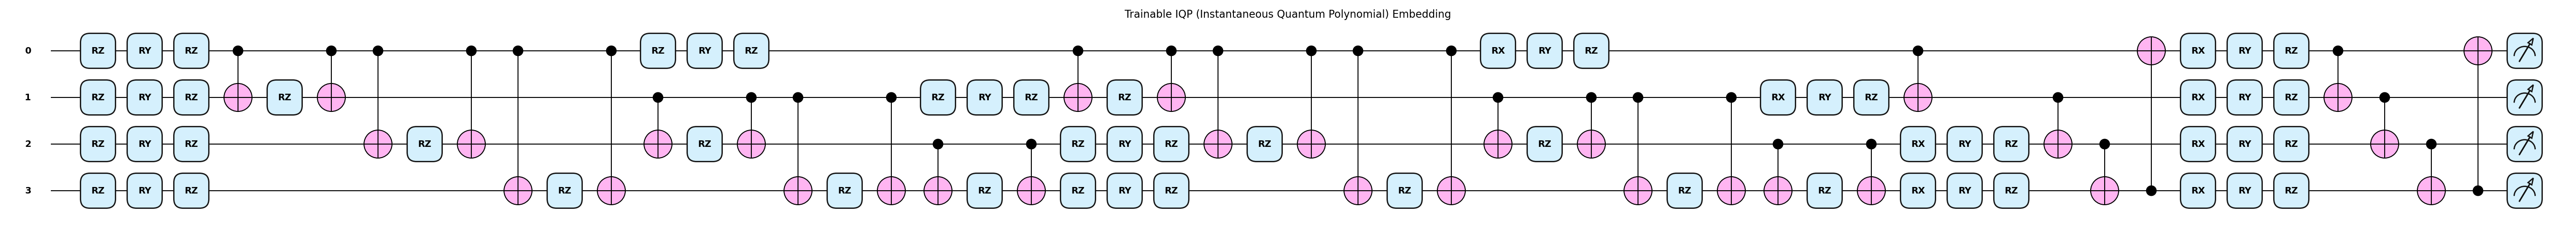

IQP 임베딩 구조:
- 임베딩 레이어: 2개
- 각 레이어: 데이터 인코딩 + 학습 가능한 ZZ 상호작용
- 임베딩 매개변수: 24개
- 안사츠 매개변수: 24개


In [23]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# 6. IQP (학습 가능한 순간 양자 다항식) 임베딩
num_qubits_iqp = 4
num_embedding_layers = 2
dev_iqp = qml.device("default.qubit", wires=num_qubits_iqp)

def data_encoding_layer(inputs):
    """U_data(x): 얽힘 없는 데이터 인코딩"""
    for i, x in enumerate(inputs):
        qml.RZ(x, wires=i)

def trainable_embedding_layer(emb_weights, layer_idx):
    """U_train(θ_emb): 학습 가능한 얽힘 계층"""
    # 단일 큐비트 회전
    for i in range(num_qubits_iqp):
        qml.RY(emb_weights[layer_idx, i, 0], wires=i)
        qml.RZ(emb_weights[layer_idx, i, 1], wires=i)
    
    # IQP 스타일 얽힘: ZZ 상호작용
    for i in range(num_qubits_iqp):
        for j in range(i + 1, num_qubits_iqp):
            # ZZ 상호작용을 CNOT으로 구현
            qml.CNOT(wires=[i, j])
            qml.RZ(emb_weights[layer_idx, i, 2] * emb_weights[layer_idx, j, 2], wires=j)
            qml.CNOT(wires=[i, j])

def iqp_embedding_block(inputs, emb_weights):
    """IQP 임베딩 블록: 데이터 인코딩과 학습 가능한 얽힘의 교대"""
    for layer in range(num_embedding_layers):
        # 데이터 재업로딩
        data_encoding_layer(inputs)
        # 학습 가능한 얽힘
        trainable_embedding_layer(emb_weights, layer)

def variational_ansatz(ansatz_weights):
    """주 변분 안사츠"""
    for i in range(2):
        # 매개변수화된 회전
        for j in range(num_qubits_iqp):
            qml.RX(ansatz_weights[i, j, 0], wires=j)
            qml.RY(ansatz_weights[i, j, 1], wires=j)
            qml.RZ(ansatz_weights[i, j, 2], wires=j)
        
        # 얽힘 레이어
        for j in range(num_qubits_iqp):
            qml.CNOT(wires=[j, (j + 1) % num_qubits_iqp])

@qml.qnode(dev_iqp)
def iqp_circuit(inputs, emb_weights, ansatz_weights):
    """
    학습 가능한 IQP 회로:
    1. IQP 임베딩 블록 (데이터 + 학습 가능한 얽힘)
    2. 변분 안사츠
    """
    
    # 1. IQP 임베딩
    iqp_embedding_block(inputs, emb_weights)
    
    # 2. 변분 안사츠
    variational_ansatz(ansatz_weights)
    
    # 측정
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits_iqp)]

# 그리기 위한 더미 입력값
dummy_inputs_iqp = np.array([0.1, 0.2, 0.3, 0.4])
# 임베딩 가중치: [레이어, 큐비트, 매개변수(RY, RZ, ZZ상호작용)]
dummy_emb_weights_iqp = np.random.normal(0, 0.1, (num_embedding_layers, num_qubits_iqp, 3))
# 안사츠 가중치: [레이어, 큐비트, 매개변수(RX, RY, RZ)]
dummy_ansatz_weights_iqp = np.zeros((2, num_qubits_iqp, 3))

# 회로 시각화 (matplotlib 백엔드 사용)
fig, ax = qml.draw_mpl(iqp_circuit, style="pennylane", expansion_strategy="device")(
    dummy_inputs_iqp, dummy_emb_weights_iqp, dummy_ansatz_weights_iqp
)
fig.suptitle("Trainable IQP (Instantaneous Quantum Polynomial) Embedding", fontsize=16)
plt.show()

print(f"IQP 임베딩 구조:")
print(f"- 임베딩 레이어: {num_embedding_layers}개")
print(f"- 각 레이어: 데이터 인코딩 + 학습 가능한 ZZ 상호작용")
print(f"- 임베딩 매개변수: {num_embedding_layers * num_qubits_iqp * 3}개")
print(f"- 안사츠 매개변수: {2 * num_qubits_iqp * 3}개")

## 7. DIFE (상쇄 간섭 충실도 추정)

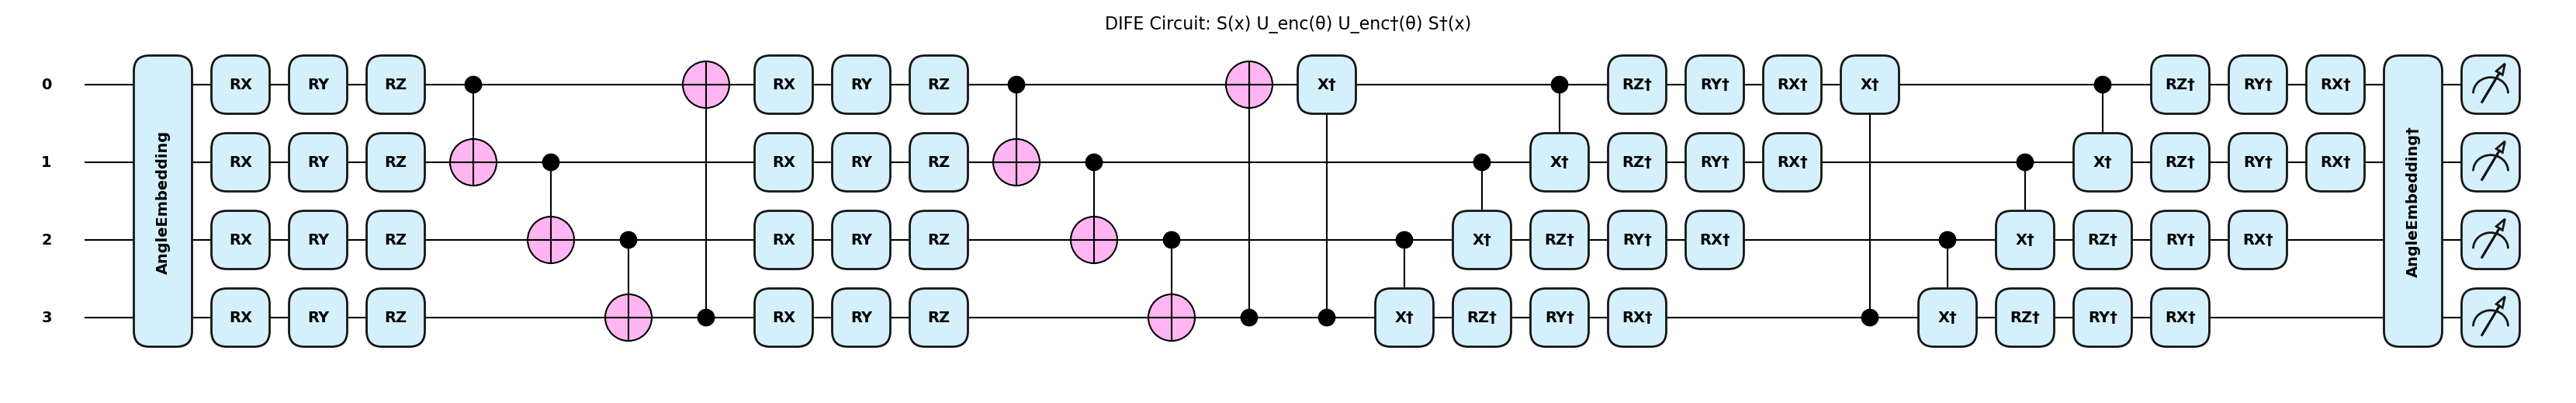

DIFE 원리:
- 순방향: S(x) U_enc(θ) |0⟩
- 역방향: U_enc†(θ) S†(x)
- 측정: |⟨0|전체회로|0⟩|² = 충실도
- 상쇄 간섭 발생 시 충실도 감소


In [24]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# 7. DIFE (상쇄 간섭 충실도 추정)
num_qubits_dife = 4
dev_dife = qml.device("default.qubit", wires=num_qubits_dife)

def data_embedding(inputs):
    """데이터 임베딩 S(x)"""
    qml.AngleEmbedding(inputs, wires=range(num_qubits_dife))

def encoder_ansatz(weights):
    """인코더 안사츠 U_enc(θ)"""
    for i in range(2):
        # 매개변수화된 단일 큐비트 회전
        for j in range(num_qubits_dife):
            qml.RX(weights[i, j, 0], wires=j)
            qml.RY(weights[i, j, 1], wires=j)
            qml.RZ(weights[i, j, 2], wires=j)
        
        # 얽힘 레이어
        for j in range(num_qubits_dife):
            qml.CNOT(wires=[j, (j + 1) % num_qubits_dife])

@qml.qnode(dev_dife)
def dife_circuit(inputs, weights):
    """
    DIFE 회로: U = S(x) U_enc(θ), 충실도 = |⟨0|U†U|0⟩|²
    
    완전한 DIFE는 다음과 같이 구성됩니다:
    1. |0⟩ 상태 준비
    2. U = S(x) U_enc(θ) 적용  
    3. U† = U_enc†(θ) S†(x) 적용
    4. |0⟩으로의 복귀 확률 측정
    
    상쇄 간섭이 일어나면 충실도가 낮아집니다.
    """
    
    # 1. 초기 상태는 자동으로 |0⟩
    
    # 2. 순방향 연산: U = S(x) U_enc(θ)
    data_embedding(inputs)      # S(x)
    encoder_ansatz(weights)     # U_enc(θ)
    
    # 3. 역방향 연산: U† = U_enc†(θ) S†(x)
    qml.adjoint(encoder_ansatz)(weights)  # U_enc†(θ)
    qml.adjoint(data_embedding)(inputs)   # S†(x)
    
    # 4. |0⟩ 상태로의 복귀 확률 측정
    # 모든 큐비트가 |0⟩ 상태에 있을 확률
    return qml.probs(wires=range(num_qubits_dife))

@qml.qnode(dev_dife)
def dife_fidelity_circuit(inputs, weights):
    """충실도 직접 계산을 위한 단순화된 회로 (시각화용)"""
    data_embedding(inputs)
    encoder_ansatz(weights)
    qml.adjoint(encoder_ansatz)(weights)
    qml.adjoint(data_embedding)(inputs)
    
    # |0⟩ 상태 확률 = 모든 큐비트의 Z 기댓값이 +1일 확률
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits_dife)]

# 그리기 위한 더미 입력값
dummy_inputs_dife = np.array([0.1, 0.2, 0.3, 0.4])
dummy_weights_dife = np.random.normal(0, 0.1, (2, num_qubits_dife, 3))

# 회로 시각화 (matplotlib 백엔드 사용)
fig, ax = qml.draw_mpl(dife_fidelity_circuit, style="pennylane", expansion_strategy="device")(
    dummy_inputs_dife, dummy_weights_dife
)
fig.suptitle("DIFE Circuit: S(x) U_enc(θ) U_enc†(θ) S†(x)", fontsize=16)
plt.show()

print("DIFE 원리:")
print("- 순방향: S(x) U_enc(θ) |0⟩")
print("- 역방향: U_enc†(θ) S†(x)")
print("- 측정: |⟨0|전체회로|0⟩|² = 충실도")
print("- 상쇄 간섭 발생 시 충실도 감소")

## 8. LS-SWAP (큐비트 효율적 잠재 공간 SWAP 테스트)

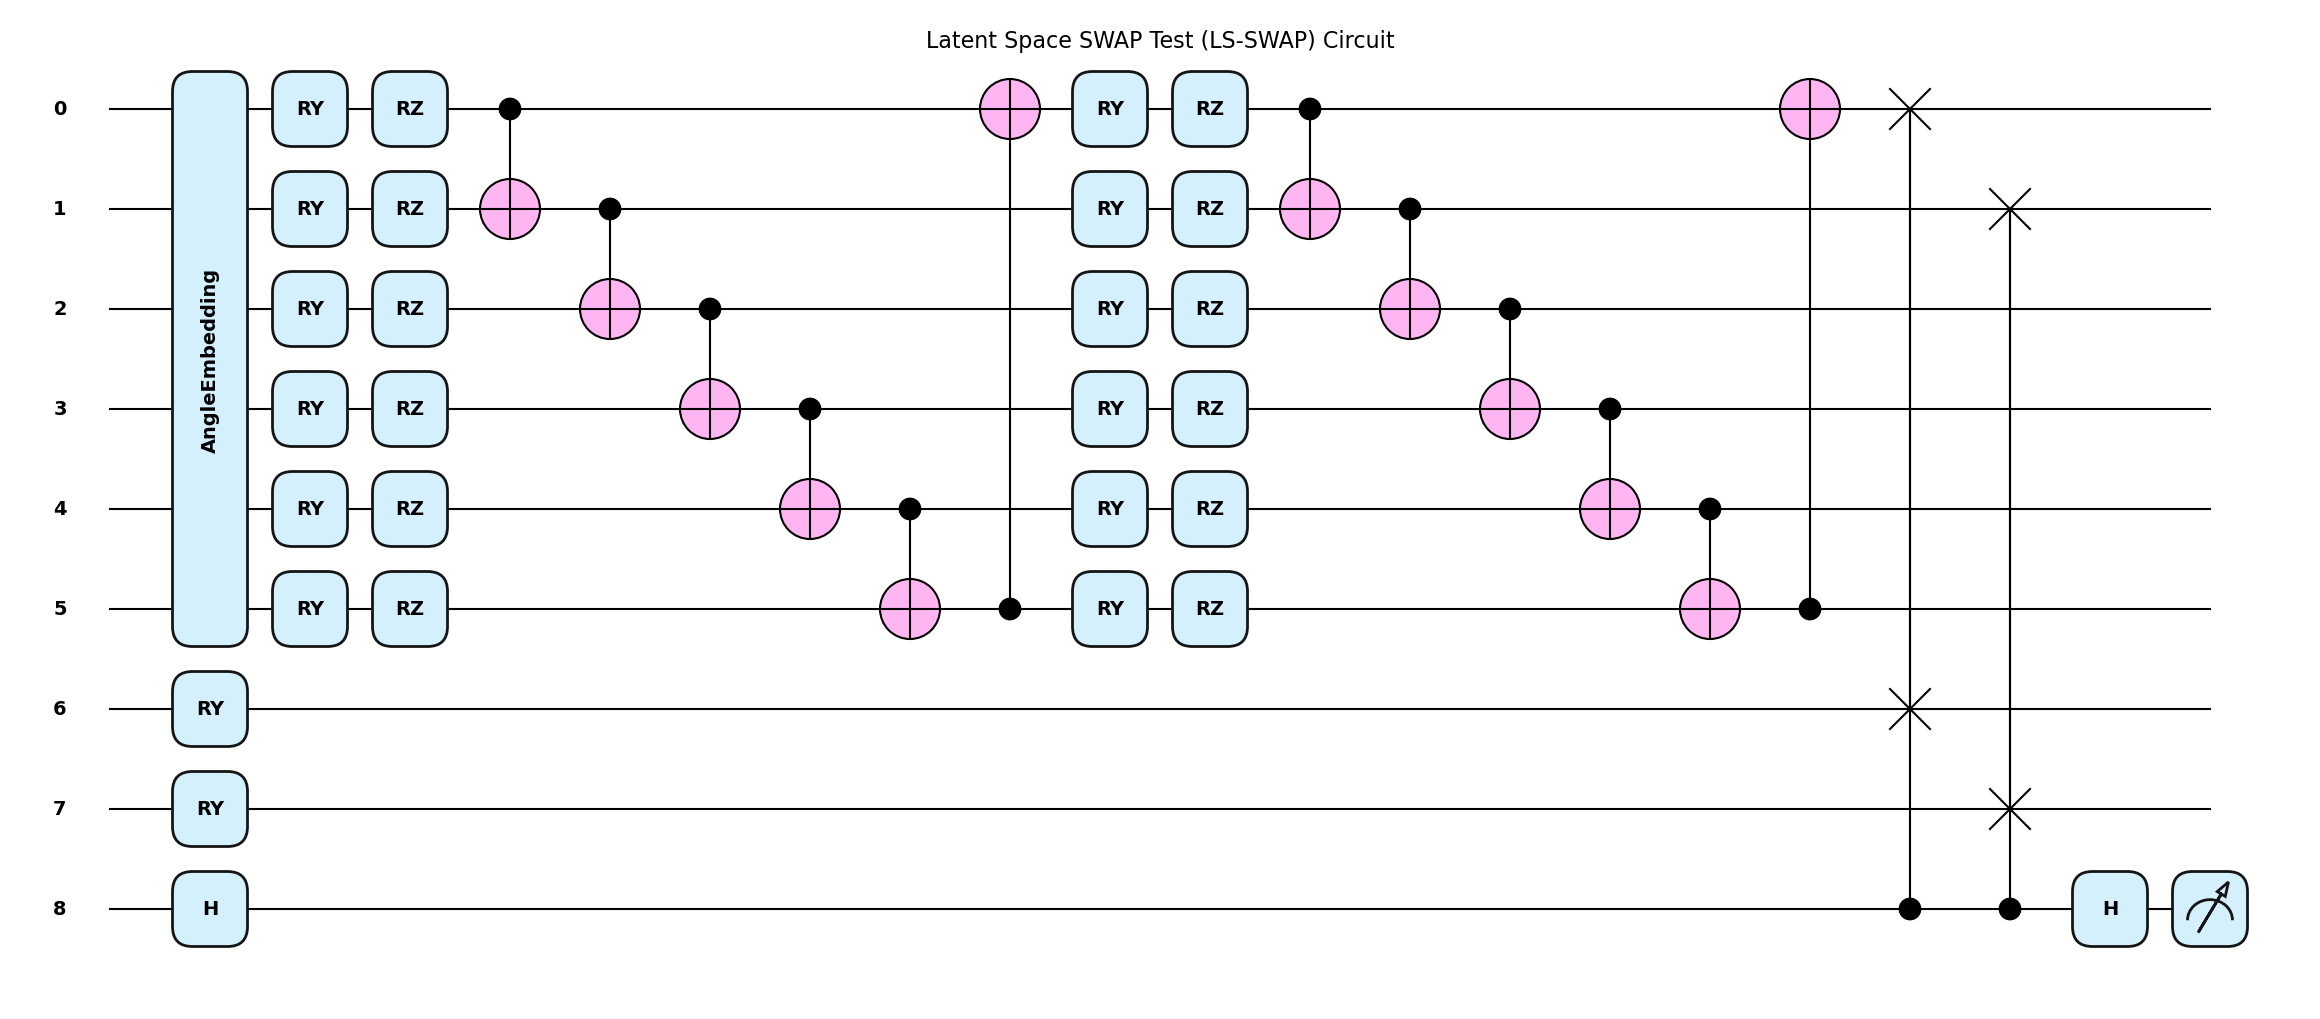

회로 구성:
- 데이터 큐비트: 6개 (큐비트 0-5)
- 잠재 공간: 2개 (큐비트 [0, 1])
- 참조 큐비트: 2개 (큐비트 6-7)
- 제어 큐비트: 1개 (큐비트 8)
SWAP 테스트 결과: ⟨Z⟩ = 2 × overlap - 1


In [25]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# 8. LS-SWAP (큐비트 효율적 잠재 공간 SWAP 테스트)
num_data_qubits_ls = 6    # 데이터 큐비트 수 감소 (시각화 개선)
num_latent_qubits_ls = 2  # 잠재 공간 큐비트
num_ref_qubits_ls = 2     # 참조 큐비트 (SWAP 테스트용)
num_control_qubits_ls = 1 # 제어 큐비트
total_qubits_ls = num_data_qubits_ls + num_ref_qubits_ls + num_control_qubits_ls

dev_ls = qml.device("default.qubit", wires=total_qubits_ls)

# 큐비트 할당
data_wires = list(range(num_data_qubits_ls))
latent_wires = [0, 1]  # 데이터 큐비트 중 잠재 공간으로 사용할 큐비트
ref_wires = list(range(num_data_qubits_ls, num_data_qubits_ls + num_ref_qubits_ls))
control_wire = total_qubits_ls - 1

def encoder_for_latent(weights):
    """잠재 공간 생성을 위한 인코더"""
    for i in range(2):
        # 모든 데이터 큐비트에 회전 게이트
        for j in data_wires:
            qml.RY(weights[i, j, 0], wires=j)
            qml.RZ(weights[i, j, 1], wires=j)
        
        # 얽힘 레이어
        for j in range(len(data_wires)):
            qml.CNOT(wires=[data_wires[j], data_wires[(j + 1) % len(data_wires)]])

def prepare_reference_state(ref_params):
    """참조 상태 준비"""
    for i, wire in enumerate(ref_wires):
        qml.RY(ref_params[i], wires=wire)

@qml.qnode(dev_ls)
def ls_swap_circuit(inputs, encoder_weights, ref_params):
    """
    LS-SWAP 테스트:
    1. 데이터 임베딩 및 인코딩으로 잠재 공간 생성
    2. 참조 상태 준비
    3. 잠재 공간과 참조 상태 간 SWAP 테스트
    4. 제어 큐비트 측정
    """
    
    # 1. 데이터 임베딩 및 인코딩
    qml.AngleEmbedding(inputs, wires=data_wires)
    encoder_for_latent(encoder_weights)
    
    # 2. 참조 상태 준비
    prepare_reference_state(ref_params)
    
    # 3. SWAP 테스트 프로토콜
    # 제어 큐비트를 중첩 상태로 준비
    qml.Hadamard(wires=control_wire)
    
    # 조건부 SWAP 연산들
    for i in range(num_latent_qubits_ls):
        latent_qubit = latent_wires[i]
        ref_qubit = ref_wires[i]
        qml.CSWAP(wires=[control_wire, latent_qubit, ref_qubit])
    
    # 제어 큐비트에 다시 Hadamard
    qml.Hadamard(wires=control_wire)
    
    # 4. 측정: ⟨Z⟩_control = 2 * overlap - 1
    return qml.expval(qml.PauliZ(control_wire))

@qml.qnode(dev_ls)
def ls_swap_visualization_circuit(inputs, encoder_weights, ref_params):
    """시각화를 위한 단순화된 LS-SWAP 회로"""
    # 데이터 처리
    qml.AngleEmbedding(inputs, wires=data_wires)
    encoder_for_latent(encoder_weights)
    
    # 참조 상태
    prepare_reference_state(ref_params)
    
    # SWAP 테스트
    qml.Hadamard(wires=control_wire)
    for i in range(num_latent_qubits_ls):
        qml.CSWAP(wires=[control_wire, latent_wires[i], ref_wires[i]])
    qml.Hadamard(wires=control_wire)
    
    return qml.expval(qml.PauliZ(control_wire))

# 그리기 위한 더미 입력값
dummy_inputs_ls = np.zeros(num_data_qubits_ls)
dummy_encoder_weights_ls = np.zeros((2, num_data_qubits_ls, 2))
dummy_ref_params_ls = np.zeros(num_ref_qubits_ls)

# 회로 시각화 (matplotlib 백엔드 사용)
fig, ax = qml.draw_mpl(ls_swap_visualization_circuit, style="pennylane", expansion_strategy="device")(
    dummy_inputs_ls, dummy_encoder_weights_ls, dummy_ref_params_ls
)
fig.suptitle("Latent Space SWAP Test (LS-SWAP) Circuit", fontsize=16)
plt.show()

print(f"회로 구성:")
print(f"- 데이터 큐비트: {num_data_qubits_ls}개 (큐비트 {min(data_wires)}-{max(data_wires)})")
print(f"- 잠재 공간: {num_latent_qubits_ls}개 (큐비트 {latent_wires})")
print(f"- 참조 큐비트: {num_ref_qubits_ls}개 (큐비트 {min(ref_wires)}-{max(ref_wires)})")
print(f"- 제어 큐비트: 1개 (큐비트 {control_wire})")
print(f"SWAP 테스트 결과: ⟨Z⟩ = 2 × overlap - 1")